<a href="https://colab.research.google.com/github/ArKaarthik06/ArKaarthik06/blob/main/diabetes_prediction_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# An Interpretable Machine Learning Framework for Diabetes Risk Prediction and Behavioral Clustering
### Course 22AIE213 – Introduction to Machine Learning | Case Study
**Dataset:** NHANES-structured Community Health Survey  
**Models:** Logistic Regression | Random Forest | XGBoost | K-Means Clustering  
**Explainability:** SHAP (SHapley Additive exPlanations)

---


## Step 0 — Install Dependencies & Upload Dataset

In [ ]:
# Install required libraries
!pip install xgboost shap -q
print("✓ All packages installed")


✓ All packages installed


In [ ]:
# Upload dataset ZIP file
from google.colab import files
import zipfile, os

print("Please upload 'dataset_diabetics_prediction.zip'")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('dataset/')

print("\n✓ Files extracted:")
for f in os.listdir('dataset/'):
    print(f"  - {f}")


Please upload 'dataset_diabetics_prediction.zip'


Saving dataset_diabetics_prediction.zip to dataset_diabetics_prediction (1).zip

✓ Files extracted:
  - medications.csv
  - examination.csv
  - labs.csv
  - demographic.csv
  - diet.csv
  - questionnaire.csv


## Step 1 — Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)
import xgboost as xgb
import shap

# Plot style
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})

SEED = 42
np.random.seed(SEED)
print("✓ All imports successful")


✓ All imports successful


## Step 2 — Data Loading & Merging
The raw data is spread across 6 survey component tables. We merge them on the common participant identifier `SEQN`.

In [ ]:
# ── Load all 6 tables ──────────────────────────────────────────
demo  = pd.read_csv('dataset/demographic.csv')
diet  = pd.read_csv('dataset/diet.csv')
exam  = pd.read_csv('dataset/examination.csv')
labs  = pd.read_csv('dataset/labs.csv')
quest = pd.read_csv('dataset/questionnaire.csv')
meds = pd.read_csv('dataset/medications.csv', encoding='latin-1')

print("Table shapes:")
for name, df in [('Demographic',demo),('Diet',diet),('Examination',exam),
                  ('Labs',labs),('Questionnaire',quest),('Medications',meds)]:
    print(f"  {name:15s}: {df.shape[0]:,} rows × {df.shape[1]} columns")


Table shapes:
  Demographic    : 10,175 rows × 47 columns
  Diet           : 9,813 rows × 168 columns
  Examination    : 9,813 rows × 224 columns
  Labs           : 9,813 rows × 424 columns
  Questionnaire  : 10,175 rows × 953 columns
  Medications    : 20,194 rows × 13 columns


### 2.1 — Feature Selection & Merge
We select 9 clinically relevant features across 4 categories. Features with >50% missingness are excluded as they cannot be reliably imputed.

In [ ]:
# ── Select clinically relevant features ────────────────────────
#
# EXCLUDED (>50% missing — too sparse to impute reliably):
#   BMIHEAD(100%), BMIRECUM(99.7%), BMIHT(97.8%), RIDAGEMN(97.2%),
#   BMILEG(96.4%), BMIARML(96.2%), BMIARMC(96.2%), BMIWT(96.1%),
#   BMIWAIST(95.5%), LBDLDL(68.4%), LBDLDLSI(68.4%), BMDBMIC(63.3%)
#
# SELECTED (≤32% missing — imputable):
selected_demo = ['SEQN', 'RIAGENDR', 'RIDAGEYR', 'DMDHRAGE']
selected_diet = ['SEQN', 'DRQSDIET', 'DR1TALCO', 'DR1TCHOL']
selected_exam = ['SEQN', 'BMXBMI', 'BMXWAIST']
selected_labs = ['SEQN', 'LBXGH']          # HbA1c — strongest diabetes indicator
selected_tgt  = ['SEQN', 'DIQ010']         # Diabetes status (target)

# Merge on SEQN
df = (demo[selected_demo]
      .merge(diet[selected_diet],  on='SEQN', how='left')
      .merge(exam[selected_exam],  on='SEQN', how='left')
      .merge(labs[selected_labs],  on='SEQN', how='left')
      .merge(quest[selected_tgt],  on='SEQN', how='left'))

print(f"Merged dataset shape: {df.shape}")
print(f"\nDIQ010 raw distribution:")
print(df['DIQ010'].value_counts(dropna=False).to_string())


Merged dataset shape: (10175, 11)

DIQ010 raw distribution:
DIQ010
2.0    8841
1.0     737
NaN     406
3.0     185
9.0       5
7.0       1


### 2.2 — Target Variable Encoding & Cleaning

In [ ]:
# ── Filter valid labels only ───────────────────────────────────
# DIQ010: 1=Diabetic, 2=Non-diabetic | Drop: 3(borderline), 7(refused), 9(unknown), NaN
df = df[df['DIQ010'].isin([1.0, 2.0])].copy()

# Binary encode: 1=Diabetic, 0=Non-Diabetic
df['Diabetes'] = (df['DIQ010'] == 1.0).astype(int)
df = df.drop(columns=['SEQN', 'DIQ010'])

print(f"Final dataset shape: {df.shape}")
print(f"\nClass Distribution:")
counts = df['Diabetes'].value_counts()
for label, count in counts.items():
    name = 'Diabetic' if label == 1 else 'Non-Diabetic'
    print(f"  {name:15s}: {count:,}  ({count/len(df)*100:.1f}%)")

# Feature summary
FEATURES = df.drop('Diabetes', axis=1).columns.tolist()
print(f"\nFeatures selected ({len(FEATURES)}):")
feature_info = {
    'RIAGENDR': 'Demographic — Gender',
    'RIDAGEYR': 'Demographic — Age (years)',
    'DMDHRAGE': 'Demographic — Household reference age',
    'DRQSDIET': 'Lifestyle — Diet quality score',
    'DR1TALCO': 'Lifestyle — Alcohol intake (gm)',
    'DR1TCHOL': 'Lifestyle — Dietary cholesterol (mg)',
    'BMXBMI'  : 'Anthropometric — Body Mass Index (kg/m²)',
    'BMXWAIST': 'Anthropometric — Waist circumference (cm)',
    'LBXGH'   : 'Laboratory — HbA1c (%)',
}
for f in FEATURES:
    print(f"  {f:12s}: {feature_info.get(f,'')}")


Final dataset shape: (9578, 10)

Class Distribution:
  Non-Diabetic   : 8,841  (92.3%)
  Diabetic       : 737  (7.7%)

Features selected (9):
  RIAGENDR    : Demographic — Gender
  RIDAGEYR    : Demographic — Age (years)
  DMDHRAGE    : Demographic — Household reference age
  DRQSDIET    : Lifestyle — Diet quality score
  DR1TALCO    : Lifestyle — Alcohol intake (gm)
  DR1TCHOL    : Lifestyle — Dietary cholesterol (mg)
  BMXBMI      : Anthropometric — Body Mass Index (kg/m²)
  BMXWAIST    : Anthropometric — Waist circumference (cm)
  LBXGH       : Laboratory — HbA1c (%)


## Step 3 — Exploratory Data Analysis (EDA)
### 3.1 — Target Variable: Class Distribution

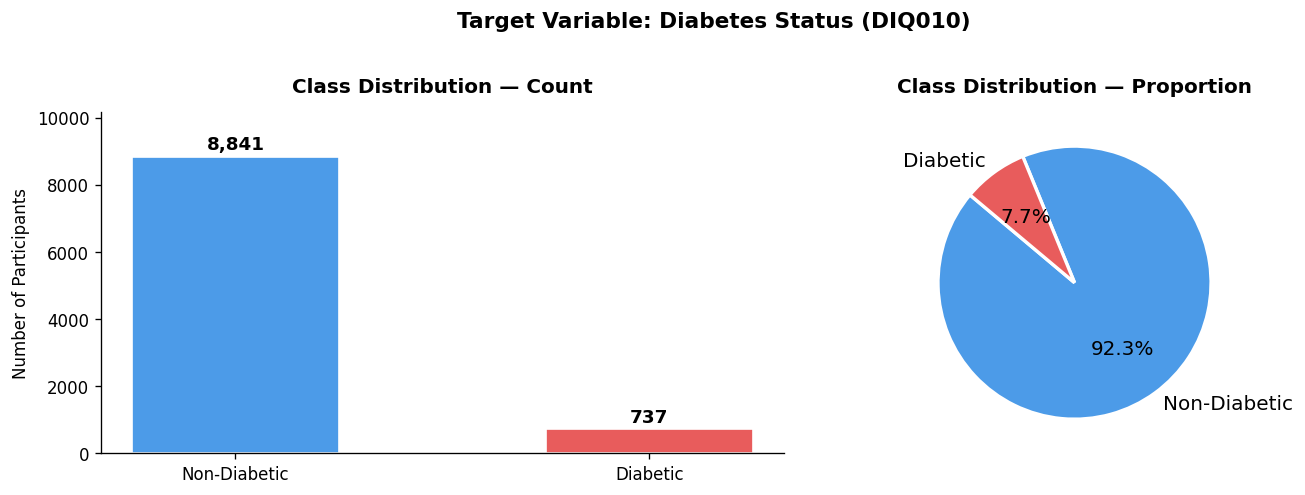

Figure 3.1 saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['Diabetes'].value_counts().sort_index()
labels = ['Non-Diabetic', 'Diabetic']
colors = ['#4C9BE8', '#E85C5C']

# Bar chart
bars = axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Class Distribution — Count', fontweight='bold', pad=12)
axes[0].set_ylabel('Number of Participants')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_ylim(0, max(counts.values) * 1.15)

# Pie chart
wedge_props = {'edgecolor': 'white', 'linewidth': 2}
pcts = counts.values / counts.values.sum() * 100
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct=lambda p: f'{p:.1f}%', startangle=140,
            wedgeprops=wedge_props, textprops={'fontsize': 12})
axes[1].set_title('Class Distribution — Proportion', fontweight='bold', pad=12)

plt.suptitle('Target Variable: Diabetes Status (DIQ010)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_3_1_class_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3.1 saved.")


### 3.2 — Demographic Analysis: Age and Diabetes Prevalence

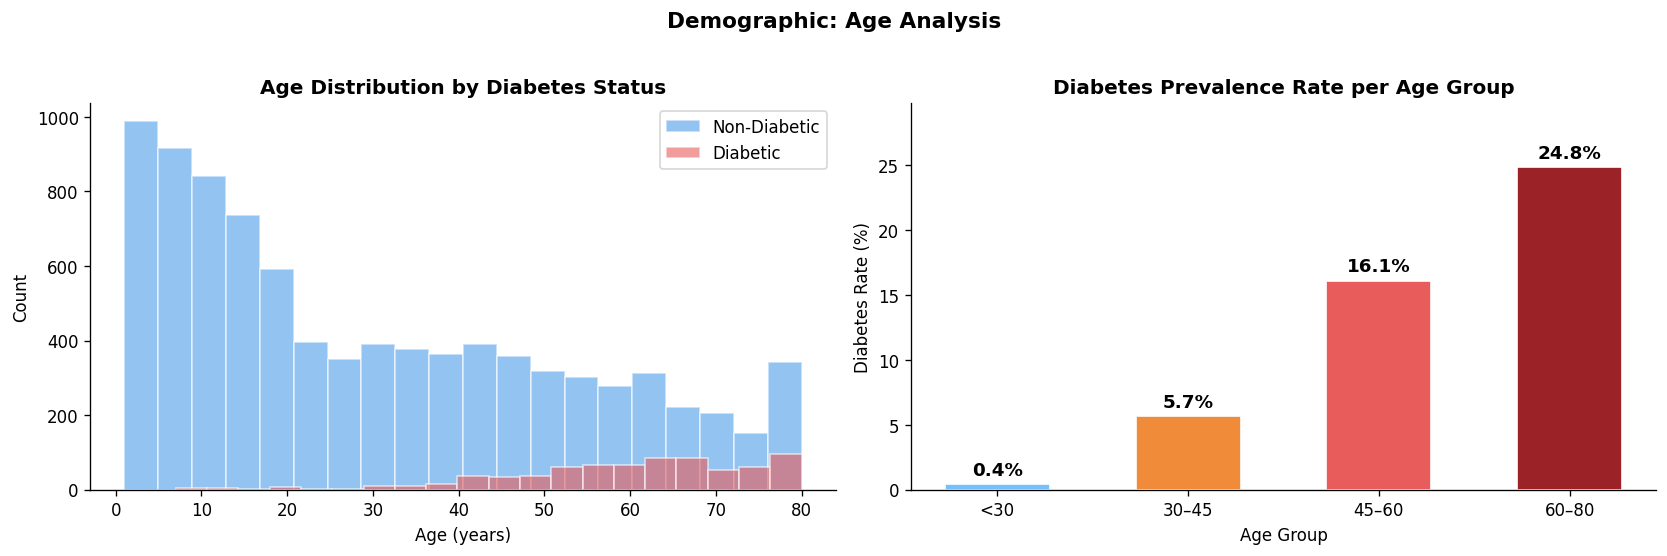

Figure 3.2 saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left — Age distribution by diabetes status
for label, color, name in [(0,'#4C9BE8','Non-Diabetic'), (1,'#E85C5C','Diabetic')]:
    subset = df[df['Diabetes'] == label]['RIDAGEYR'].dropna()
    axes[0].hist(subset, bins=20, alpha=0.6, color=color, label=name, edgecolor='white')
axes[0].set_title('Age Distribution by Diabetes Status', fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Right — prevalence by age group
df['AgeGroup'] = pd.cut(df['RIDAGEYR'],
                         bins=[0, 30, 45, 60, 100],
                         labels=['<30', '30–45', '45–60', '60–80'])
prev = df.groupby('AgeGroup', observed=True)['Diabetes'].mean() * 100

bar_colors = ['#74C0FC','#F08C39','#E85C5C','#9B2226']
bars = axes[1].bar(prev.index.astype(str), prev.values, color=bar_colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, prev.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_title('Diabetes Prevalence Rate per Age Group', fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Diabetes Rate (%)')
axes[1].set_ylim(0, max(prev.values) * 1.2)

plt.suptitle('Demographic: Age Analysis', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_3_2_age_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
df = df.drop(columns=['AgeGroup'])
print("Figure 3.2 saved.")


### 3.3 — Clinical Features: BMI and Waist Circumference

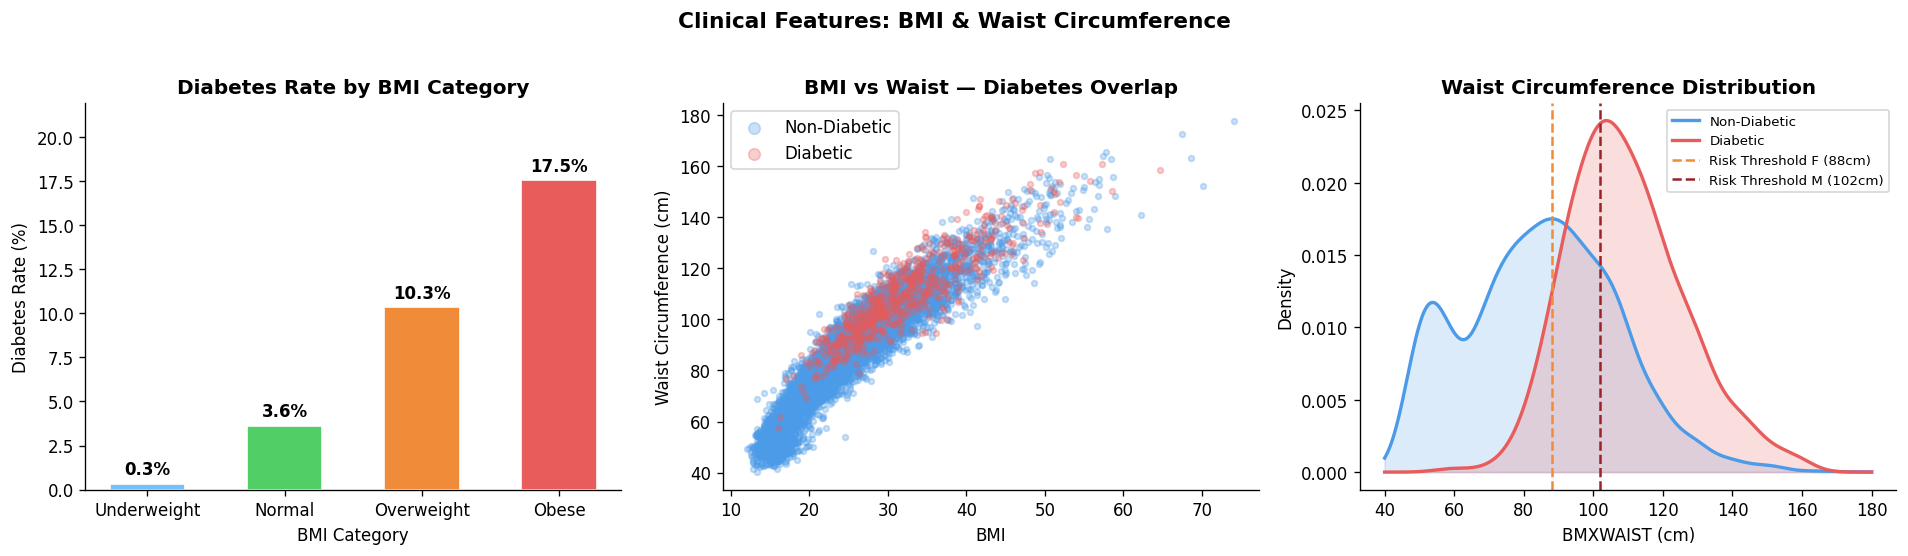

Figure 3.3 saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Left — diabetes rate by BMI category
df['BMI_Cat'] = pd.cut(df['BMXBMI'],
                        bins=[0, 18.5, 25, 30, 100],
                        labels=['Underweight','Normal','Overweight','Obese'])
bmi_prev = df.groupby('BMI_Cat', observed=True)['Diabetes'].mean() * 100
cat_colors = ['#74C0FC','#51CF66','#F08C39','#E85C5C']
bars = axes[0].bar(bmi_prev.index.astype(str), bmi_prev.values,
                   color=cat_colors, edgecolor='white', width=0.55)
for bar, val in zip(bars, bmi_prev.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
axes[0].set_title('Diabetes Rate by BMI Category', fontweight='bold')
axes[0].set_xlabel('BMI Category')
axes[0].set_ylabel('Diabetes Rate (%)')
axes[0].set_ylim(0, max(bmi_prev.values) * 1.25)

# Centre — scatter BMI vs Waist
for label, color, name in [(0,'#4C9BE8','Non-Diabetic'), (1,'#E85C5C','Diabetic')]:
    sub = df[df['Diabetes'] == label]
    axes[1].scatter(sub['BMXBMI'], sub['BMXWAIST'], alpha=0.3,
                    s=12, c=color, label=name)
axes[1].set_title('BMI vs Waist — Diabetes Overlap', fontweight='bold')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Waist Circumference (cm)')
axes[1].legend(markerscale=2)

# Right — KDE waist circumference
from scipy.stats import gaussian_kde
for label, color, name in [(0,'#4C9BE8','Non-Diabetic'), (1,'#E85C5C','Diabetic')]:
    vals = df[df['Diabetes'] == label]['BMXWAIST'].dropna()
    kde = gaussian_kde(vals)
    x_range = np.linspace(40, 180, 300)
    axes[2].plot(x_range, kde(x_range), color=color, lw=2, label=name)
    axes[2].fill_between(x_range, kde(x_range), alpha=0.2, color=color)
axes[2].axvline(88, color='#F08C39', linestyle='--', lw=1.5, label='Risk Threshold F (88cm)')
axes[2].axvline(102, color='#9B2226', linestyle='--', lw=1.5, label='Risk Threshold M (102cm)')
axes[2].set_title('Waist Circumference Distribution', fontweight='bold')
axes[2].set_xlabel('BMXWAIST (cm)')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=8)

plt.suptitle('Clinical Features: BMI & Waist Circumference', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_3_3_bmi_waist.png', bbox_inches='tight', dpi=150)
plt.show()
df = df.drop(columns=['BMI_Cat'])
print("Figure 3.3 saved.")


### 3.4 — Laboratory Feature: HbA1c Distribution

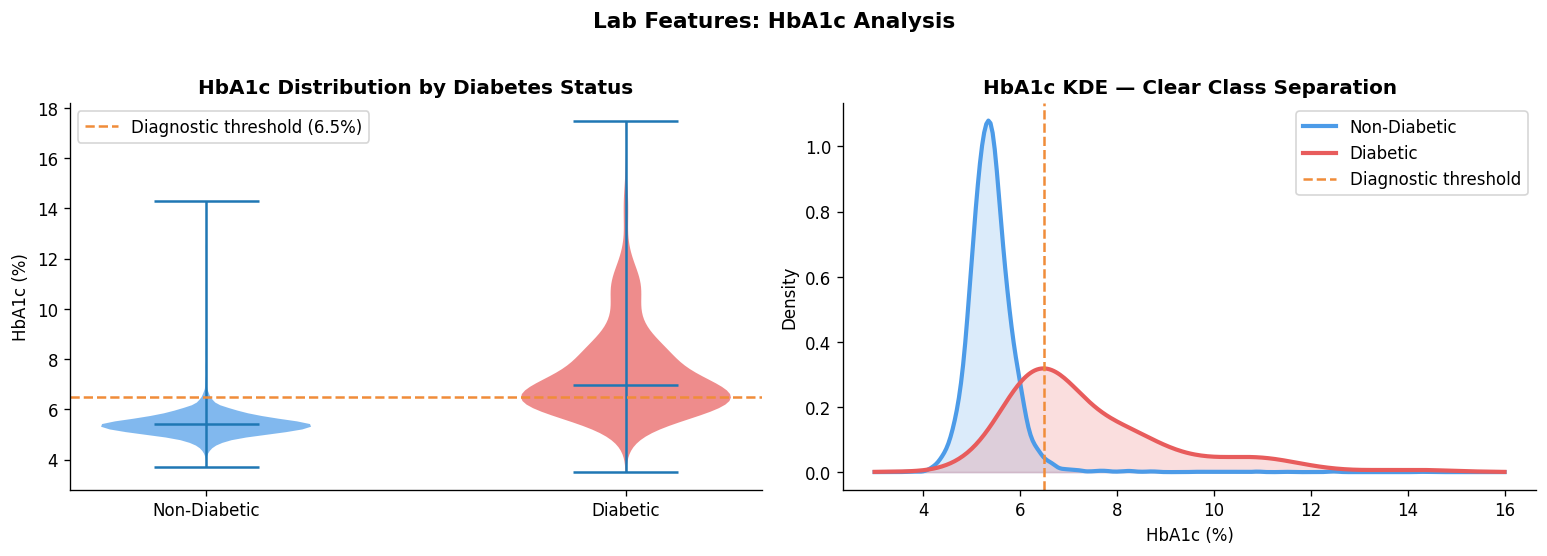

Figure 3.4 saved.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

colors = ['#4C9BE8', '#E85C5C']
labels_str = ['Non-Diabetic', 'Diabetic']

# Left — violin
violin_data = [df[df['Diabetes']==0]['LBXGH'].dropna(),
               df[df['Diabetes']==1]['LBXGH'].dropna()]
parts = axes[0].violinplot(violin_data, positions=[0,1], showmedians=True, showextrema=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(labels_str)
axes[0].set_title('HbA1c Distribution by Diabetes Status', fontweight='bold')
axes[0].set_ylabel('HbA1c (%)')
axes[0].axhline(6.5, color='#F08C39', linestyle='--', lw=1.5, label='Diagnostic threshold (6.5%)')
axes[0].legend()

# Right — KDE
for label, color, name in [(0,'#4C9BE8','Non-Diabetic'), (1,'#E85C5C','Diabetic')]:
    vals = df[df['Diabetes'] == label]['LBXGH'].dropna()
    vals = vals[vals < 20]
    kde = gaussian_kde(vals)
    x_range = np.linspace(3, 16, 300)
    axes[1].plot(x_range, kde(x_range), color=color, lw=2.5, label=name)
    axes[1].fill_between(x_range, kde(x_range), alpha=0.2, color=color)
axes[1].axvline(6.5, color='#F08C39', linestyle='--', lw=1.5, label='Diagnostic threshold')
axes[1].set_title('HbA1c KDE — Clear Class Separation', fontweight='bold')
axes[1].set_xlabel('HbA1c (%)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Lab Features: HbA1c Analysis', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_3_4_hba1c.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3.4 saved.")


### 3.5 — Feature Correlation with Diabetes Target

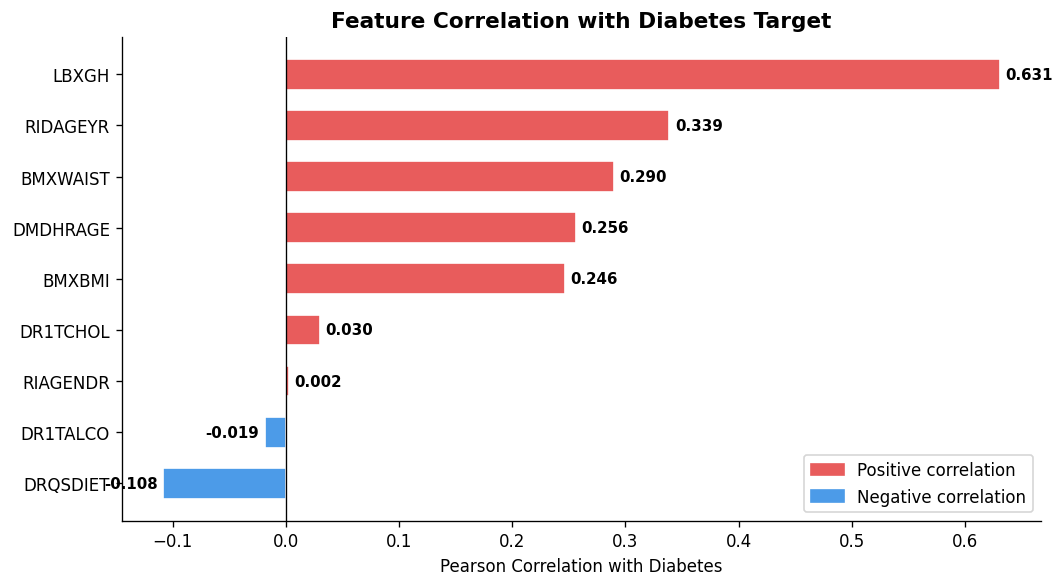

Figure 3.5 saved.

Correlation values:
LBXGH       0.630687
RIDAGEYR    0.338776
BMXWAIST    0.289858
DMDHRAGE    0.255971
BMXBMI      0.246448
DR1TCHOL    0.029864
RIAGENDR    0.002440
DR1TALCO   -0.018541
DRQSDIET   -0.108159


In [ ]:
correlations = df.corr(numeric_only=True)['Diabetes'].drop('Diabetes').sort_values()

colors_corr = ['#4C9BE8' if v < 0 else '#E85C5C' for v in correlations.values]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(correlations.index, correlations.values, color=colors_corr, edgecolor='white', height=0.6)
for bar, val in zip(bars, correlations.values):
    xpos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Correlation with Diabetes Target', fontweight='bold', fontsize=13)
ax.set_xlabel('Pearson Correlation with Diabetes')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#E85C5C', label='Positive correlation'),
                   Patch(color='#4C9BE8', label='Negative correlation')],
          loc='lower right')
plt.tight_layout()
plt.savefig('fig_3_5_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 3.5 saved.")
print("\nCorrelation values:")
print(correlations.sort_values(ascending=False).to_string())


## Step 4 — Data Preprocessing
### 4.1 — Missing Value Analysis (Before Imputation)

Missing value summary (before imputation):
---------------------------------------------
Feature            Missing %   Missing Count
---------------------------------------------
LBXGH                  32.4%           3,107
DR1TCHOL               15.5%           1,486
DR1TALCO               15.5%           1,486
DRQSDIET               14.1%           1,348
BMXWAIST               11.4%           1,091
BMXBMI                  7.4%             705
---------------------------------------------


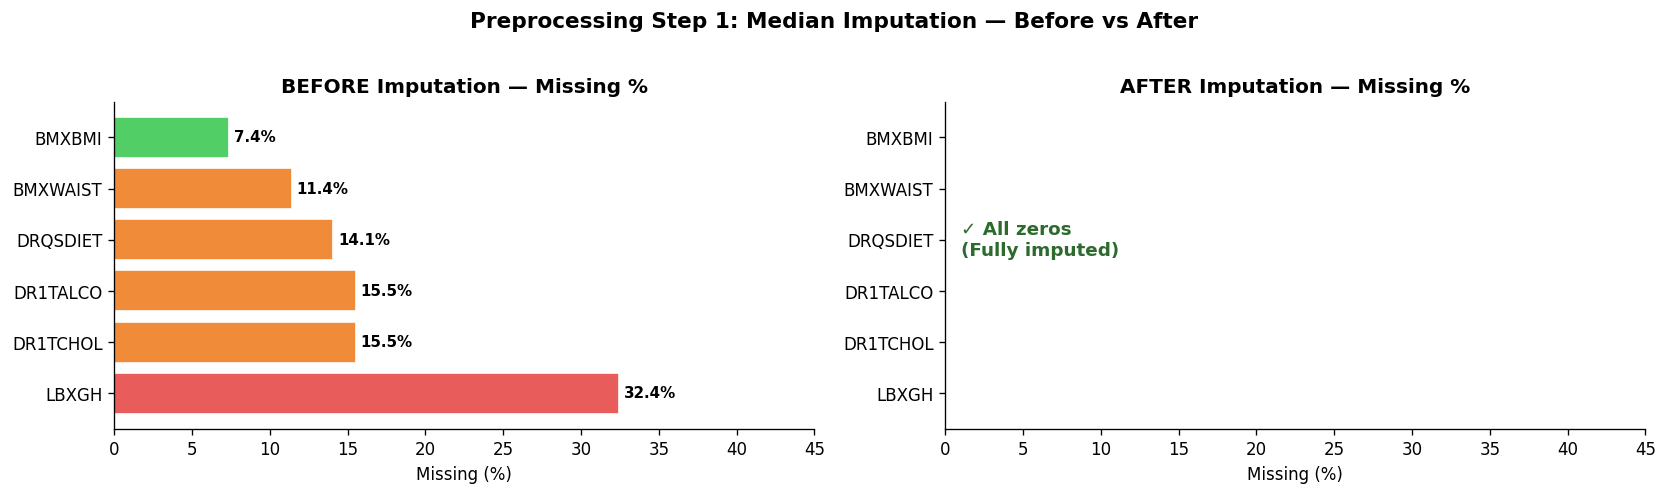

Figure 4.1 saved.


In [ ]:
X_raw = df.drop('Diabetes', axis=1)
missing_pct = (X_raw.isnull().sum() / len(X_raw) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]  # only features with missing values

print("Missing value summary (before imputation):")
print("-" * 45)
print(f"{'Feature':<15} {'Missing %':>12} {'Missing Count':>15}")
print("-" * 45)
for feat, pct in missing_pct.items():
    count = int(pct/100 * len(X_raw))
    print(f"{feat:<15} {pct:>11.1f}% {count:>15,}")
print("-" * 45)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
colors_miss = ['#E85C5C' if p > 20 else '#F08C39' if p > 10 else '#51CF66'
               for p in missing_pct.values]
axes[0].barh(missing_pct.index, missing_pct.values, color=colors_miss, edgecolor='white')
for i, (feat, val) in enumerate(missing_pct.items()):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('BEFORE Imputation — Missing %', fontweight='bold')
axes[0].set_xlabel('Missing (%)')
axes[0].set_xlim(0, 45)

# After (will be 0 — shown for contrast)
after_missing = pd.Series(0, index=missing_pct.index)
axes[1].barh(after_missing.index, after_missing.values, color='#51CF66', edgecolor='white')
axes[1].text(1, len(after_missing)/2, '✓ All zeros\n(Fully imputed)',
             va='center', fontsize=11, fontweight='bold', color='#2d6a2d')
axes[1].set_title('AFTER Imputation — Missing %', fontweight='bold')
axes[1].set_xlabel('Missing (%)')
axes[1].set_xlim(0, 45)

plt.suptitle('Preprocessing Step 1: Median Imputation — Before vs After',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_4_1_missing_values.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 4.1 saved.")


### 4.2 — Preprocessing Pipeline: Imputation + Scaling + Split

In [ ]:
from sklearn.pipeline import Pipeline

X = df.drop('Diabetes', axis=1)
y = df['Diabetes']

# ── Step 1: Train-Test Split (BEFORE imputation to prevent leakage) ──
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)
print(f"Train set : {X_train_raw.shape[0]:,} samples  |  Diabetic: {y_train.sum():,} ({y_train.mean()*100:.1f}%)")
print(f"Test  set : {X_test_raw.shape[0]:,} samples  |  Diabetic: {y_test.sum():,}  ({y_test.mean()*100:.1f}%)")

# ── Step 2: Imputation (fit on TRAIN only, transform both) ──────────
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

# ── Step 3: StandardScaler (fit on TRAIN only) ──────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_test  = scaler.transform(X_test_imp)

print("\n✓ Imputation fit on training set only — no data leakage")
print("✓ Scaler fit on training set only — no data leakage")
print(f"\nFinal feature matrix shape:")
print(f"  X_train: {X_train.shape}  |  X_test: {X_test.shape}")

FEATURE_NAMES = X.columns.tolist()
# Class imbalance ratio (for XGBoost scale_pos_weight)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio (neg/pos): {pos_weight:.1f}  → used as XGBoost scale_pos_weight")


Train set : 7,662 samples  |  Diabetic: 590 (7.7%)
Test  set : 1,916 samples  |  Diabetic: 147  (7.7%)

✓ Imputation fit on training set only — no data leakage
✓ Scaler fit on training set only — no data leakage

Final feature matrix shape:
  X_train: (7662, 9)  |  X_test: (1916, 9)

Class imbalance ratio (neg/pos): 12.0  → used as XGBoost scale_pos_weight


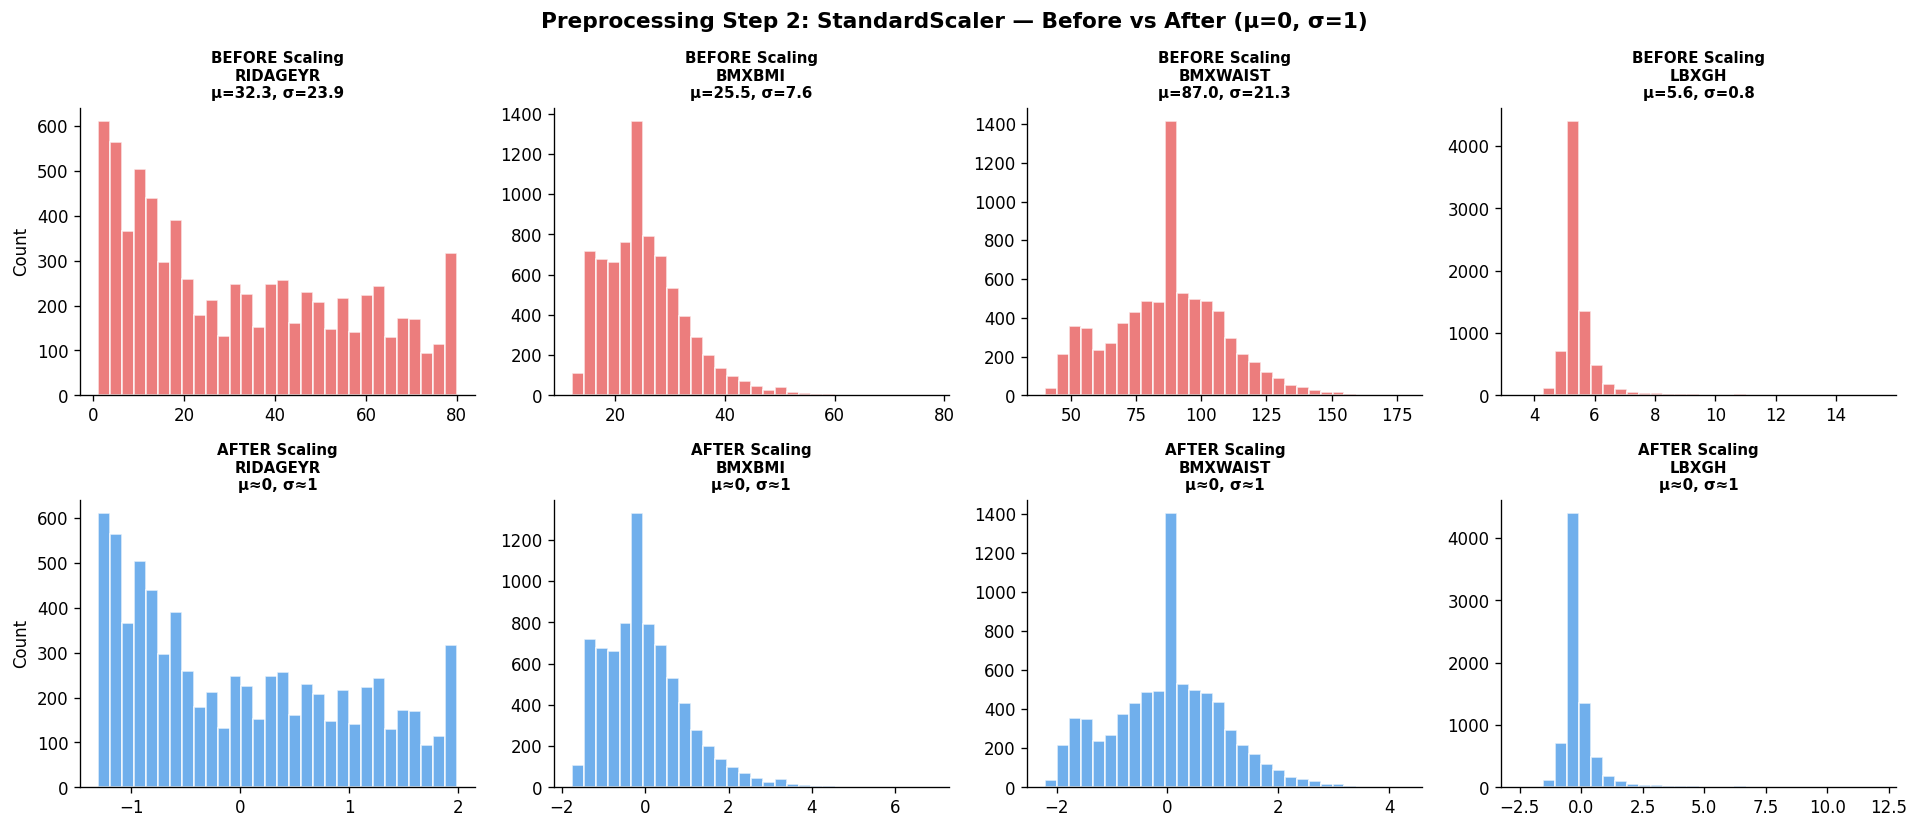

Figure 4.2 saved.


In [ ]:
# Visualize feature distributions before vs after scaling
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
show_features = ['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'LBXGH']
raw_arr = np.array(X_train_imp)

for i, feat in enumerate(show_features):
    idx = FEATURE_NAMES.index(feat)
    # Before scaling
    axes[0, i].hist(raw_arr[:, idx], bins=30, color='#E85C5C', alpha=0.8, edgecolor='white')
    mu = np.nanmean(raw_arr[:, idx])
    si = np.nanstd(raw_arr[:, idx])
    axes[0, i].set_title(f'BEFORE Scaling\n{feat}\nμ={mu:.1f}, σ={si:.1f}', fontsize=9, fontweight='bold')
    axes[0, i].set_ylabel('Count' if i == 0 else '')
    # After scaling
    axes[1, i].hist(X_train[:, idx], bins=30, color='#4C9BE8', alpha=0.8, edgecolor='white')
    axes[1, i].set_title(f'AFTER Scaling\n{feat}\nμ≈0, σ≈1', fontsize=9, fontweight='bold')
    axes[1, i].set_ylabel('Count' if i == 0 else '')

plt.suptitle('Preprocessing Step 2: StandardScaler — Before vs After (μ=0, σ=1)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_4_2_scaling.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 4.2 saved.")


## Step 5 — Model Training
### 5.1 — All Three Models

In [ ]:
# ══════════════════════════════════════════════════════════════
# MODEL 1 — Logistic Regression (Baseline)
# Reason: Interpretable linear baseline; class_weight='balanced' handles imbalance
# ══════════════════════════════════════════════════════════════
lr_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=SEED
)
lr_model.fit(X_train, y_train)
lr_pred  = lr_model.predict(X_test)
lr_prob  = lr_model.predict_proba(X_test)[:, 1]
print("✓ Logistic Regression trained")

# ══════════════════════════════════════════════════════════════
# MODEL 2 — Random Forest
# Reason: Ensemble of decision trees; handles non-linear feature interactions
# ══════════════════════════════════════════════════════════════
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)
rf_model.fit(X_train, y_train)
rf_pred  = rf_model.predict(X_test)
rf_prob  = rf_model.predict_proba(X_test)[:, 1]
print("✓ Random Forest trained")

# ══════════════════════════════════════════════════════════════
# MODEL 3 — XGBoost (Primary Model)
# Reason: Gradient boosting with regularization; best on structured tabular data
# scale_pos_weight handles class imbalance natively
# ══════════════════════════════════════════════════════════════
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    scale_pos_weight=pos_weight,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
print("✓ XGBoost trained")
print("\n✓ All models trained successfully.")


✓ Logistic Regression trained
✓ Random Forest trained
✓ XGBoost trained

✓ All models trained successfully.


## Step 6 — Results and Evaluation
### 6.1 — Metric Summary Table

In [ ]:
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 6),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 6),
        'Recall'   : round(recall_score(y_true, y_pred), 6),
        'F1-score' : round(f1_score(y_true, y_pred), 6),
        'AUROC'    : round(roc_auc_score(y_true, y_prob), 6)
    }

results = {
    'Logistic Regression': get_metrics(y_test, lr_pred,  lr_prob),
    'Random Forest'      : get_metrics(y_test, rf_pred,  rf_prob),
    'XGBoost'            : get_metrics(y_test, xgb_pred, xgb_prob),
}

results_df = pd.DataFrame(results).T
print("=" * 70)
print("MODEL EVALUATION RESULTS")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)
print(f"\n✓ Best model: {results_df['AUROC'].idxmax()} (AUROC = {results_df['AUROC'].max():.6f})")
print(f"  Best accuracy: {results_df['Accuracy'].max()*100:.2f}%")

# Individual tables matching report format
for model_name, metrics in results.items():
    print(f"\n  Results: {model_name}")
    print(f"  {'Metric':<12} {'Value':>10}")
    print(f"  {'-'*24}")
    for k, v in metrics.items():
        print(f"  {k:<12} {v:>10.6f}")


MODEL EVALUATION RESULTS
                     Accuracy  Precision    Recall  F1-score     AUROC
Logistic Regression  0.872651   0.364146  0.884354  0.515873  0.949297
Random Forest        0.947808   0.632768  0.761905  0.691358  0.955978
XGBoost              0.943111   0.610465  0.714286  0.658307  0.953577

✓ Best model: Random Forest (AUROC = 0.955978)
  Best accuracy: 94.78%

  Results: Logistic Regression
  Metric            Value
  ------------------------
  Accuracy       0.872651
  Precision      0.364146
  Recall         0.884354
  F1-score       0.515873
  AUROC          0.949297

  Results: Random Forest
  Metric            Value
  ------------------------
  Accuracy       0.947808
  Precision      0.632768
  Recall         0.761905
  F1-score       0.691358
  AUROC          0.955978

  Results: XGBoost
  Metric            Value
  ------------------------
  Accuracy       0.943111
  Precision      0.610465
  Recall         0.714286
  F1-score       0.658307
  AUROC          0

### 6.2 — Overfitting & Generalization Analysis (Train vs Test)

In [ ]:
train_results = {
    'Logistic Regression': get_metrics(y_train, lr_model.predict(X_train),  lr_model.predict_proba(X_train)[:,1]),
    'Random Forest'      : get_metrics(y_train, rf_model.predict(X_train),  rf_model.predict_proba(X_train)[:,1]),
    'XGBoost'            : get_metrics(y_train, xgb_model.predict(X_train), xgb_model.predict_proba(X_train)[:,1]),
}

print(f"{'Model':<22} {'Train Acc':>10} {'Test Acc':>10} {'Train AUC':>11} {'Test AUC':>10} {'Train F1':>10} {'Test F1':>9}")
print("-" * 90)
for model in results:
    ta  = train_results[model]['Accuracy']
    tea = results[model]['Accuracy']
    tr  = train_results[model]['AUROC']
    ter = results[model]['AUROC']
    tf  = train_results[model]['F1-score']
    tef = results[model]['F1-score']
    print(f"{model:<22} {ta:>10.6f} {tea:>10.6f} {tr:>11.6f} {ter:>10.6f} {tf:>10.6f} {tef:>9.6f}")


Model                   Train Acc   Test Acc   Train AUC   Test AUC   Train F1   Test F1
------------------------------------------------------------------------------------------
Logistic Regression      0.869486   0.872651    0.948858   0.949297   0.506417  0.515873
Random Forest            0.969068   0.947808    0.993285   0.955978   0.827887  0.691358
XGBoost                  0.987862   0.943111    0.999741   0.953577   0.926944  0.658307


### 6.3 — Performance Comparison Bar Chart

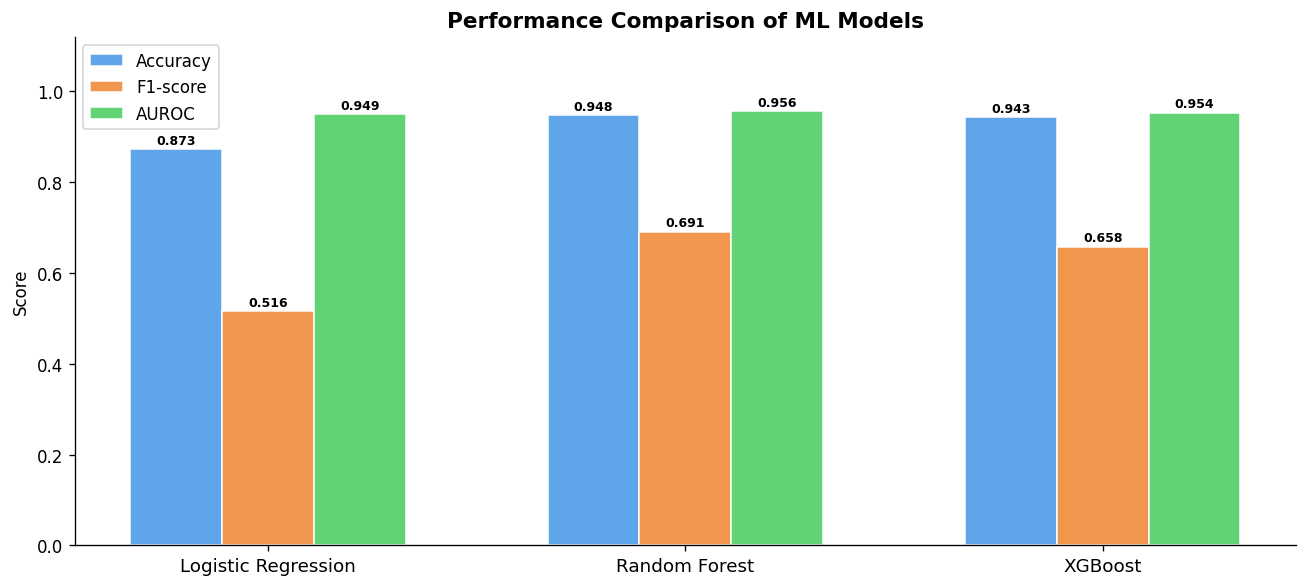

Figure 6.3 saved.


In [ ]:
metrics_to_plot = ['Accuracy', 'F1-score', 'AUROC']
model_names = list(results.keys())
x = np.arange(len(model_names))
width = 0.22
bar_colors = ['#4C9BE8', '#F08C39', '#51CF66']

fig, ax = plt.subplots(figsize=(11, 5))
for i, metric in enumerate(metrics_to_plot):
    vals = [results[m][metric] for m in model_names]
    offset = (i - 1) * width
    bars = ax.bar(x + offset, vals, width, label=metric,
                  color=bar_colors[i], edgecolor='white', alpha=0.9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Performance Comparison of ML Models', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('fig_6_3_model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 6.3 saved.")


### 6.4 — Confusion Matrix Analysis

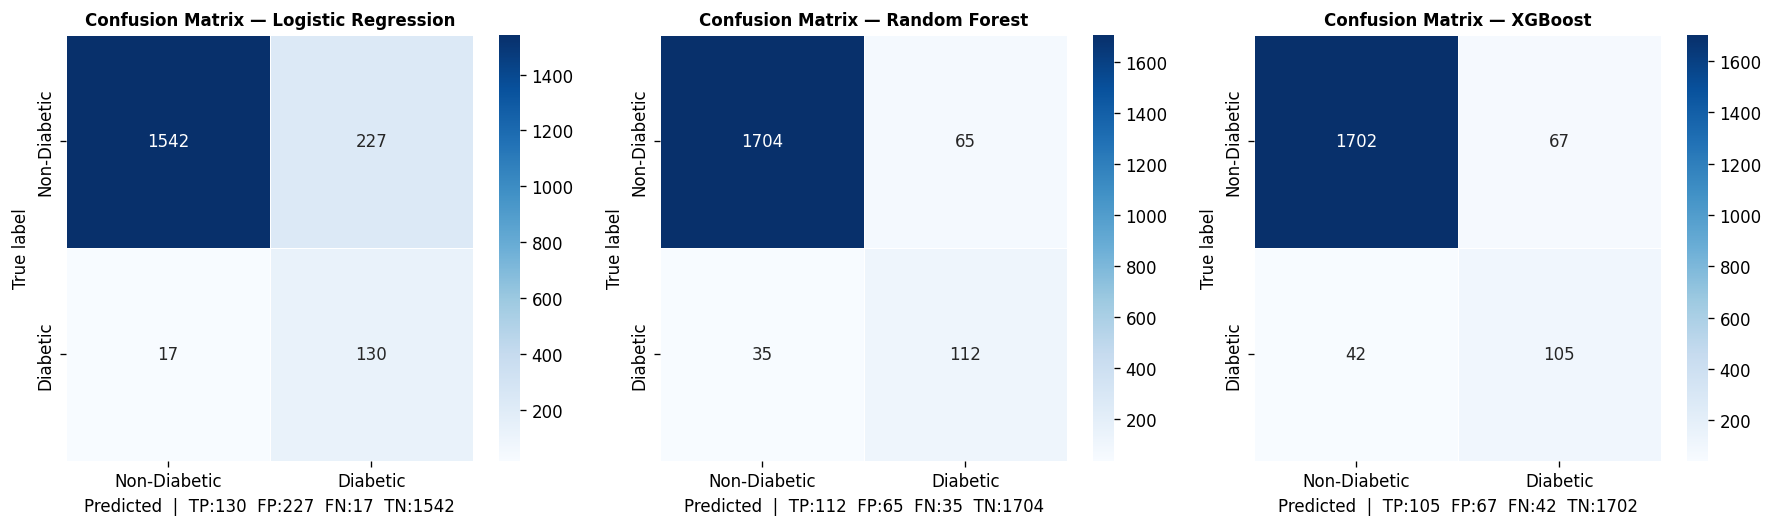

Figure 6.4 saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
model_preds = [('Logistic Regression', lr_pred),
               ('Random Forest', rf_pred),
               ('XGBoost', xgb_pred)]

for ax, (name, pred) in zip(axes, model_preds):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar=True, linewidths=0.5,
                xticklabels=['Non-Diabetic','Diabetic'],
                yticklabels=['Non-Diabetic','Diabetic'])
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted  |  TP:{tp}  FP:{fp}  FN:{fn}  TN:{tn}')

plt.tight_layout()
plt.savefig('fig_6_4_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 6.4 saved.")


### 6.5 — ROC Curve Comparison

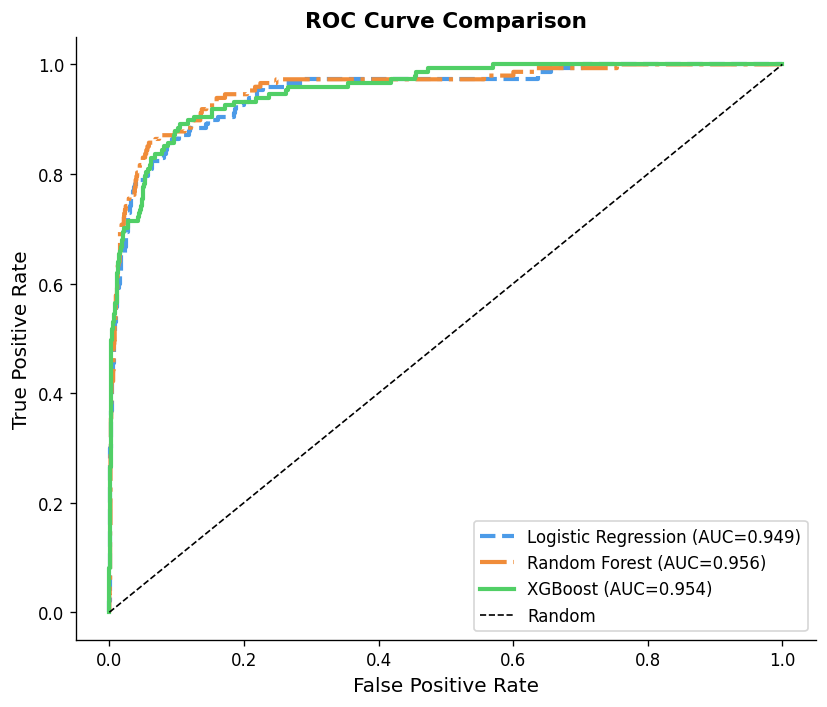

Figure 6.5 saved.


In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_data = [
    ('Logistic Regression', lr_prob,  '#4C9BE8', '--'),
    ('Random Forest',       rf_prob,  '#F08C39', '-.'),
    ('XGBoost',             xgb_prob, '#51CF66', '-'),
]
for name, prob, color, ls in plot_data:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2.5, linestyle=ls, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve Comparison', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('fig_6_5_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 6.5 saved.")


### 6.6 — Precision–Recall Curve Analysis

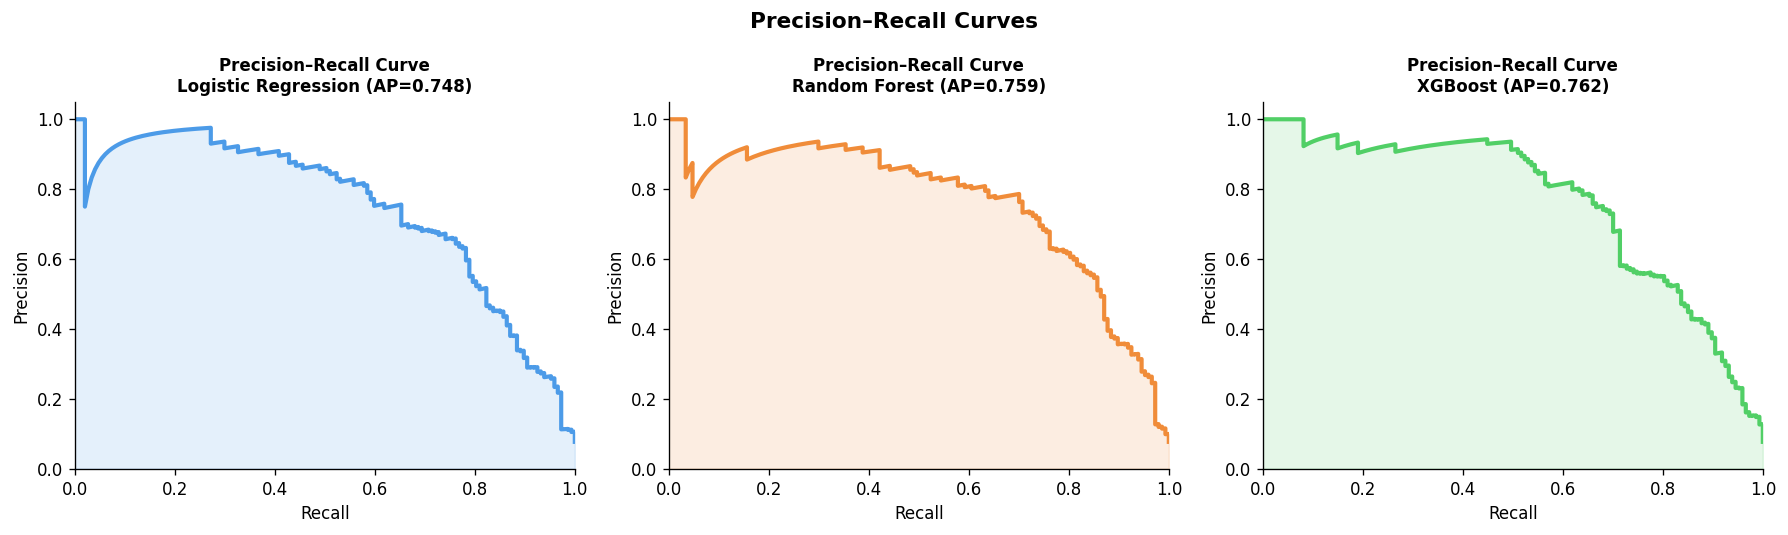

Figure 6.6 saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, prob, color, ls) in zip(axes, plot_data):
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax.plot(rec, prec, color=color, lw=2.5)
    ax.fill_between(rec, prec, alpha=0.15, color=color)
    ax.set_title(f'Precision–Recall Curve\n{name} (AP={ap:.3f})', fontweight='bold', fontsize=10)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 1)

plt.suptitle('Precision–Recall Curves', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_6_6_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 6.6 saved.")


### 6.7 — Prediction Confidence Distribution

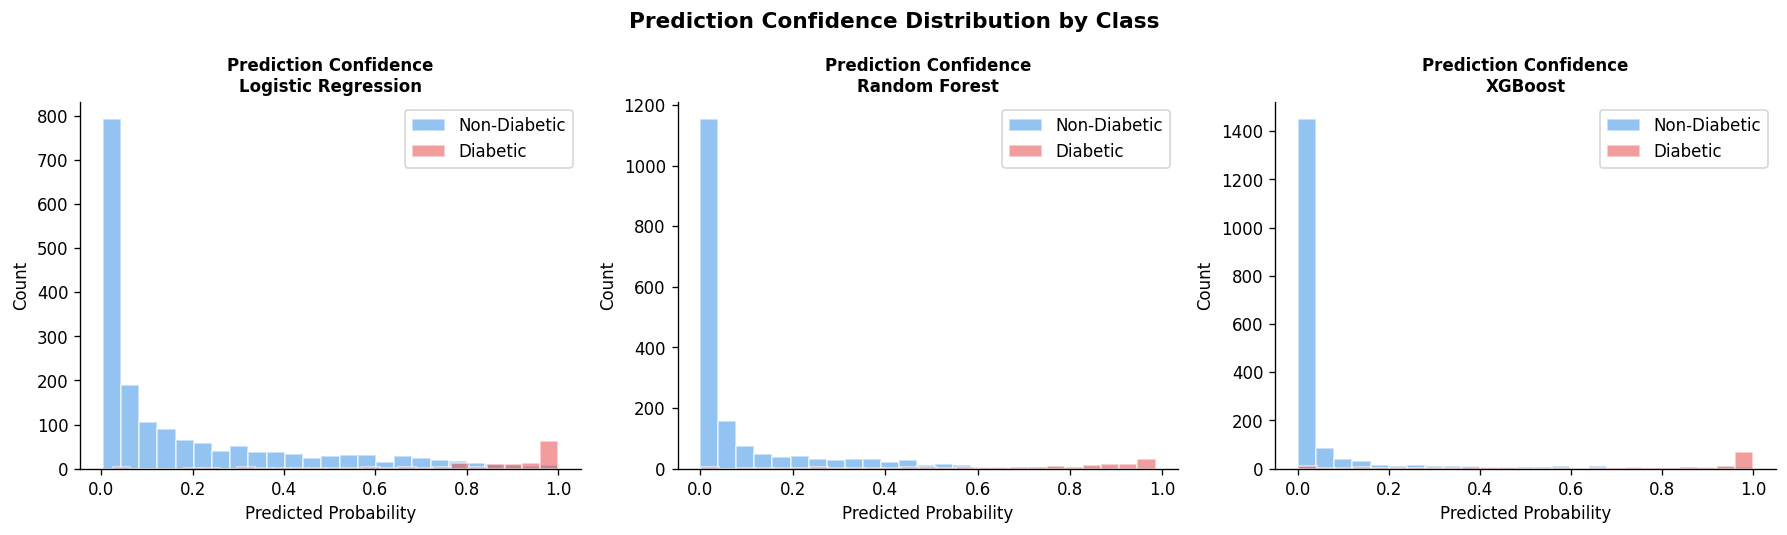

Figure 6.7 saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, prob, color, ls) in zip(axes, plot_data):
    for label, lcolor, lname in [(0,'#4C9BE8','Non-Diabetic'), (1,'#E85C5C','Diabetic')]:
        mask = y_test == label
        ax.hist(prob[mask], bins=25, alpha=0.6, color=lcolor, label=lname,
                density=False, edgecolor='white')
    ax.set_title(f'Prediction Confidence\n{name}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.legend()

plt.suptitle('Prediction Confidence Distribution by Class', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_6_7_confidence.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 6.7 saved.")


## Step 7 — SHAP Explainability Analysis (XGBoost)
### 7.1 — Global Feature Importance

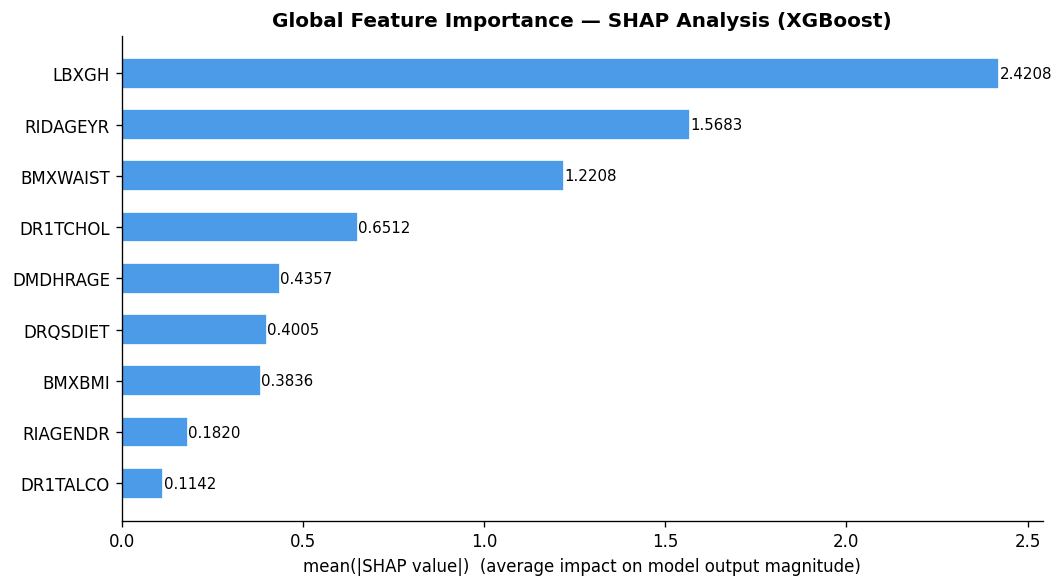

Figure 7.1 saved.

Feature Importance (SHAP):
  LBXGH          : 2.4208
  RIDAGEYR       : 1.5683
  BMXWAIST       : 1.2208
  DR1TCHOL       : 0.6512
  DMDHRAGE       : 0.4357
  DRQSDIET       : 0.4005
  BMXBMI         : 0.3836
  RIAGENDR       : 0.1820
  DR1TALCO       : 0.1142


In [ ]:
# SHAP explainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# Global importance — bar plot
fig, ax = plt.subplots(figsize=(9, 5))
mean_shap = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(mean_shap)
sorted_features = [FEATURE_NAMES[i] for i in sorted_idx]
sorted_vals = mean_shap[sorted_idx]

ax.barh(sorted_features, sorted_vals, color='#4C9BE8', edgecolor='white', height=0.6)
ax.set_xlabel('mean(|SHAP value|)  (average impact on model output magnitude)')
ax.set_title('Global Feature Importance — SHAP Analysis (XGBoost)', fontweight='bold', fontsize=12)
for i, val in enumerate(sorted_vals):
    ax.text(val + 0.002, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig_7_1_shap_global.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 7.1 saved.")
print("\nFeature Importance (SHAP):")
for feat, val in sorted(zip(FEATURE_NAMES, mean_shap), key=lambda x: -x[1]):
    print(f"  {feat:<15}: {val:.4f}")


### 7.2 — SHAP Summary Plot (Beeswarm)

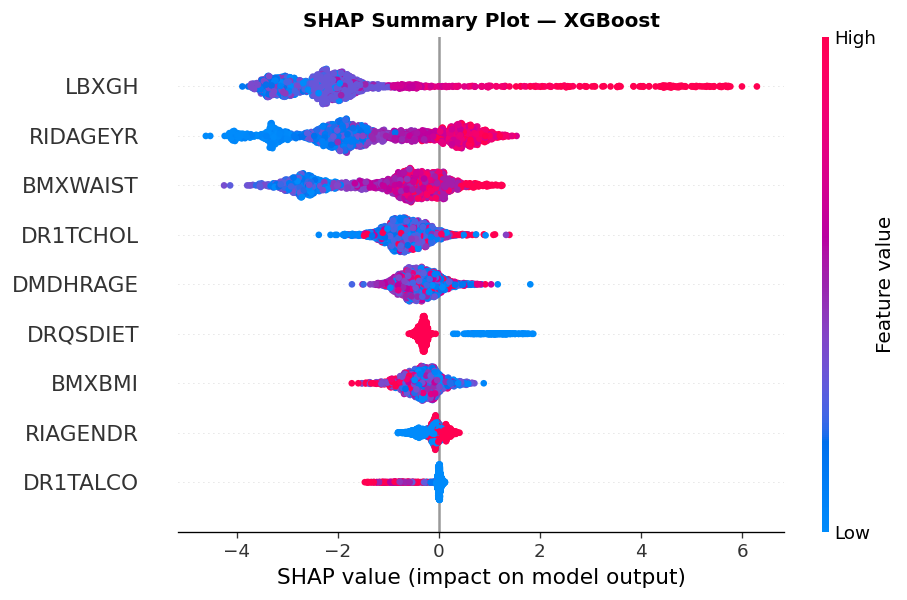

Figure 7.2 saved.


In [ ]:
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_NAMES,
    plot_type='dot',
    show=False,
    max_display=9
)
plt.title('SHAP Summary Plot — XGBoost', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig_7_2_shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 7.2 saved.")


### 7.3 — Local SHAP Explanation: Diabetic Patient

Sample index: 84  |  True label: Diabetic  |  Predicted: Diabetic
Prediction probability: 0.9948


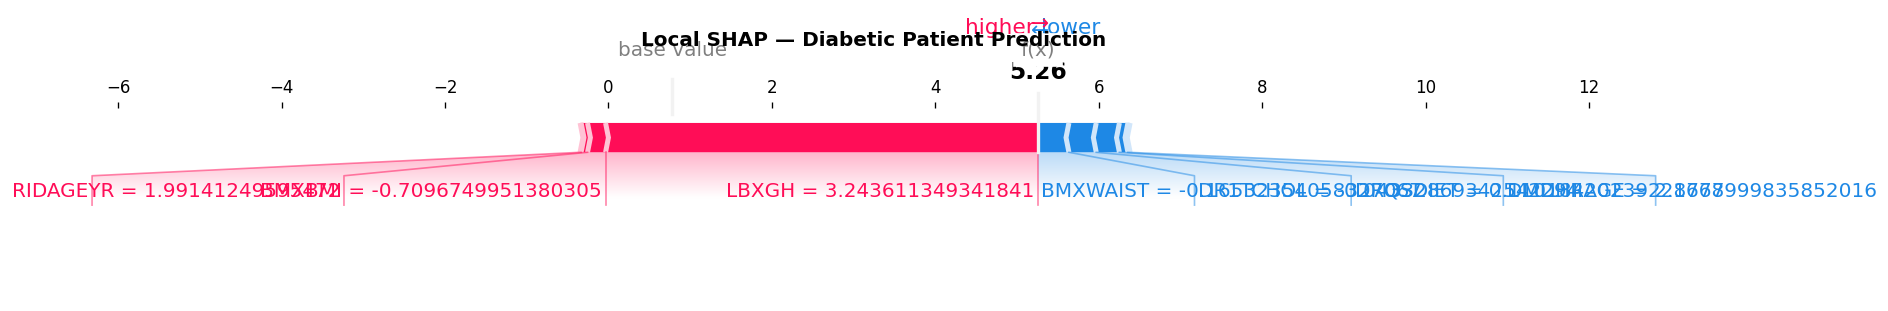

Figure 7.3 saved.


In [ ]:
# Find a correctly classified diabetic patient
diabetic_idx = np.where((y_test.values == 1) & (xgb_pred == 1))[0]
sample_idx = diabetic_idx[0]

print(f"Sample index: {sample_idx}  |  True label: Diabetic  |  Predicted: Diabetic")
print(f"Prediction probability: {xgb_prob[sample_idx]:.4f}")

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test[sample_idx],
    feature_names=FEATURE_NAMES,
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)
plt.title('Local SHAP — Diabetic Patient Prediction', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig_7_3_shap_local_diabetic.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 7.3 saved.")


### 7.4 — Local SHAP Explanation: Non-Diabetic Patient

Sample index: 1  |  True label: Non-Diabetic  |  Predicted: Non-Diabetic
Prediction probability: 0.0057


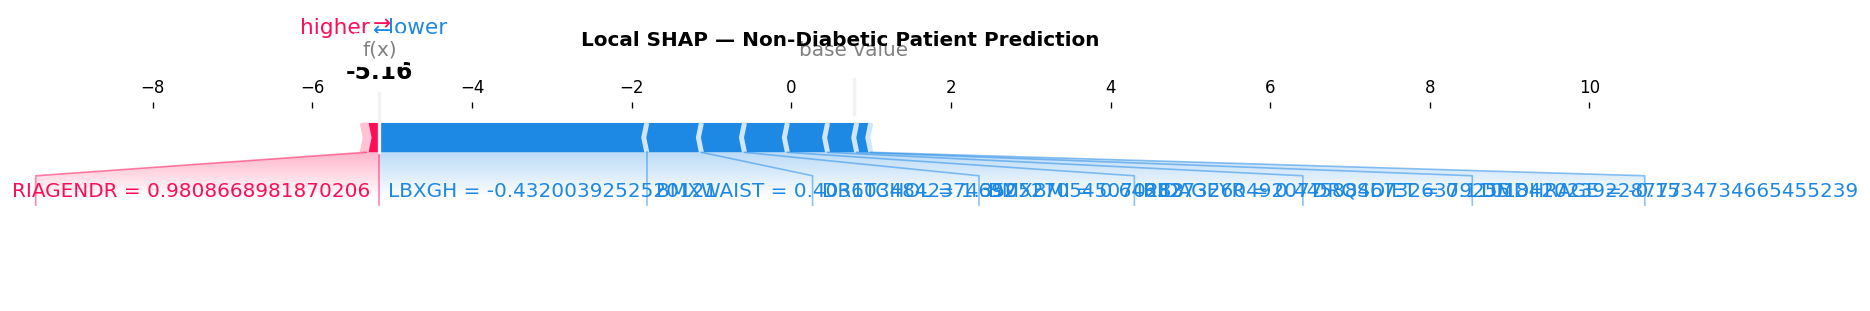

Figure 7.4 saved.


In [ ]:
non_diab_idx = np.where((y_test.values == 0) & (xgb_pred == 0))[0]
sample_idx2 = non_diab_idx[0]

print(f"Sample index: {sample_idx2}  |  True label: Non-Diabetic  |  Predicted: Non-Diabetic")
print(f"Prediction probability: {xgb_prob[sample_idx2]:.4f}")

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx2],
    X_test[sample_idx2],
    feature_names=FEATURE_NAMES,
    matplotlib=True,
    show=False,
    figsize=(16, 3)
)
plt.title('Local SHAP — Non-Diabetic Patient Prediction', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig_7_4_shap_local_nondiabetic.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 7.4 saved.")


### 7.5 — SHAP Dependence Plots (Non-Linear Feature Effects)

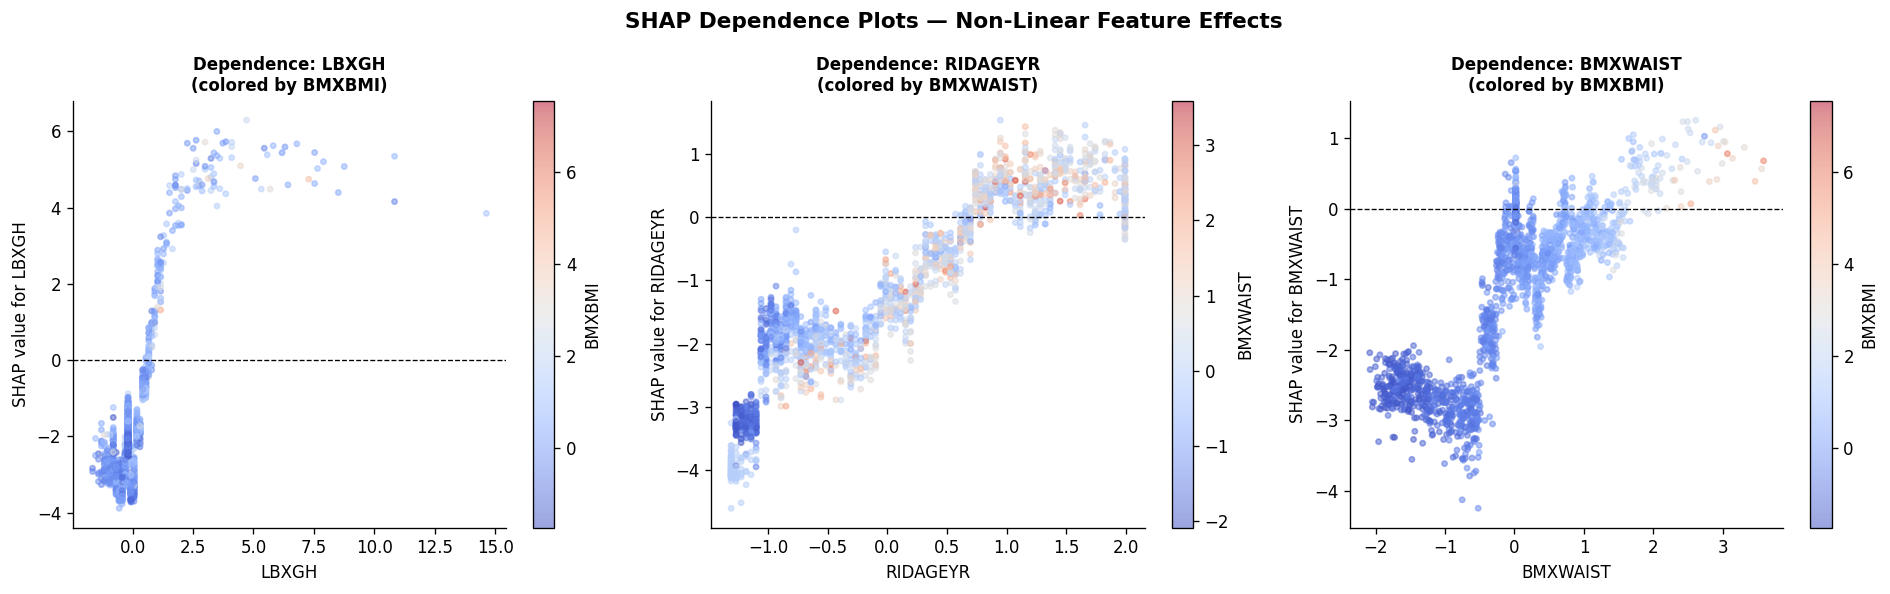

Figure 7.5 saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
dep_features = ['LBXGH', 'RIDAGEYR', 'BMXWAIST']
interact_features = ['BMXBMI', 'BMXWAIST', 'BMXBMI']

for ax, feat, interact in zip(axes, dep_features, interact_features):
    feat_idx = FEATURE_NAMES.index(feat)
    interact_idx = FEATURE_NAMES.index(interact)
    sc = ax.scatter(
        X_test[:, feat_idx],
        shap_values[:, feat_idx],
        c=X_test[:, interact_idx],
        cmap='coolwarm', alpha=0.5, s=10
    )
    plt.colorbar(sc, ax=ax, label=interact)
    ax.set_xlabel(feat)
    ax.set_ylabel(f'SHAP value for {feat}')
    ax.set_title(f'Dependence: {feat}\n(colored by {interact})', fontweight='bold', fontsize=10)
    ax.axhline(0, color='black', lw=0.8, linestyle='--')

plt.suptitle('SHAP Dependence Plots — Non-Linear Feature Effects',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig_7_5_shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure 7.5 saved.")


## Step 8 — Behavioral Clustering: K-Means
### 8.1 — Optimal K (Elbow + Silhouette)

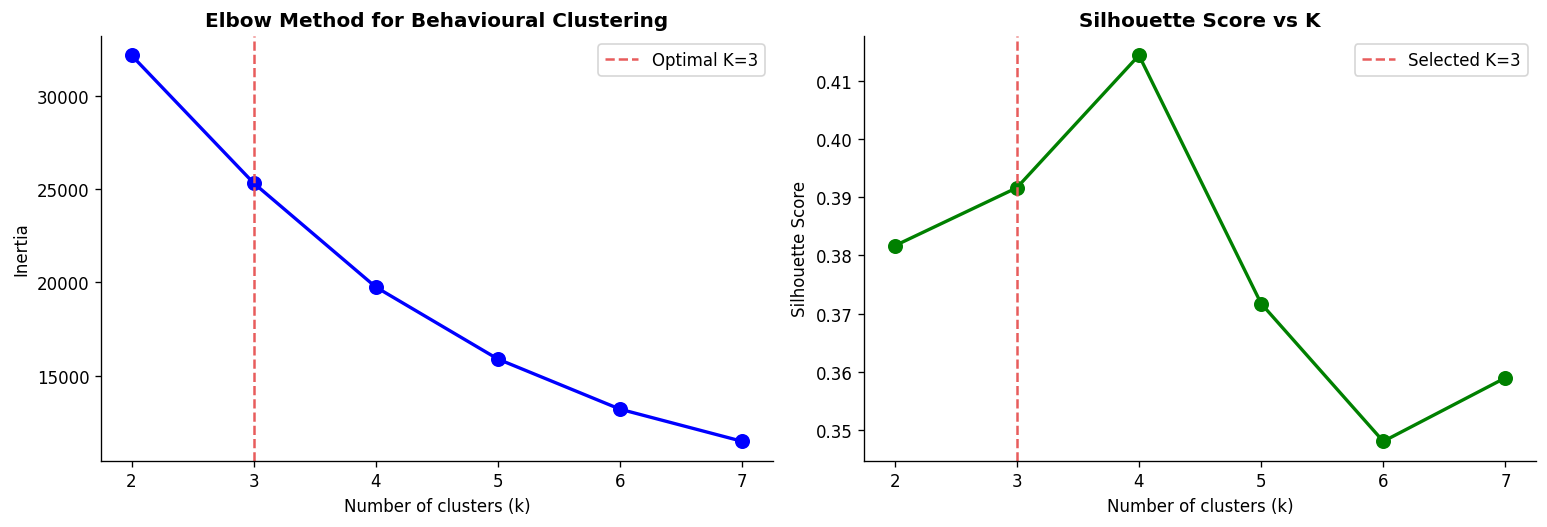

K vs Inertia:
  K=2  Inertia=   32192.6  Silhouette=0.382
  K=3  Inertia=   25334.4  Silhouette=0.392
  K=4  Inertia=   19752.3  Silhouette=0.414
  K=5  Inertia=   15885.8  Silhouette=0.372
  K=6  Inertia=   13196.5  Silhouette=0.348
  K=7  Inertia=   11471.0  Silhouette=0.359


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Use behavioural + anthropometric features for clustering
cluster_features = ['RIDAGEYR', 'BMXBMI', 'BMXWAIST', 'DRQSDIET', 'DR1TALCO']
X_cluster_raw = df[cluster_features].copy()
imp_c = SimpleImputer(strategy='median')
X_cluster = imp_c.fit_transform(X_cluster_raw)
scaler_c = StandardScaler()
X_cluster_sc = scaler_c.fit_transform(X_cluster)

k_range = range(2, 8)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_cluster_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cluster_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(k_range), inertias, 'bo-', lw=2, ms=8)
axes[0].set_title('Elbow Method for Behavioural Clustering', fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(3, color='#E85C5C', linestyle='--', lw=1.5, label='Optimal K=3')
axes[0].legend()

axes[1].plot(list(k_range), silhouettes, 'go-', lw=2, ms=8)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].axvline(3, color='#E85C5C', linestyle='--', lw=1.5, label='Selected K=3')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig_8_1_elbow_silhouette.png', bbox_inches='tight', dpi=150)
plt.show()

print("K vs Inertia:")
for k, iner, sil in zip(k_range, inertias, silhouettes):
    print(f"  K={k}  Inertia={iner:>10.1f}  Silhouette={sil:.3f}")


### 8.2 — Cluster Fitting, Profiling & Visualization

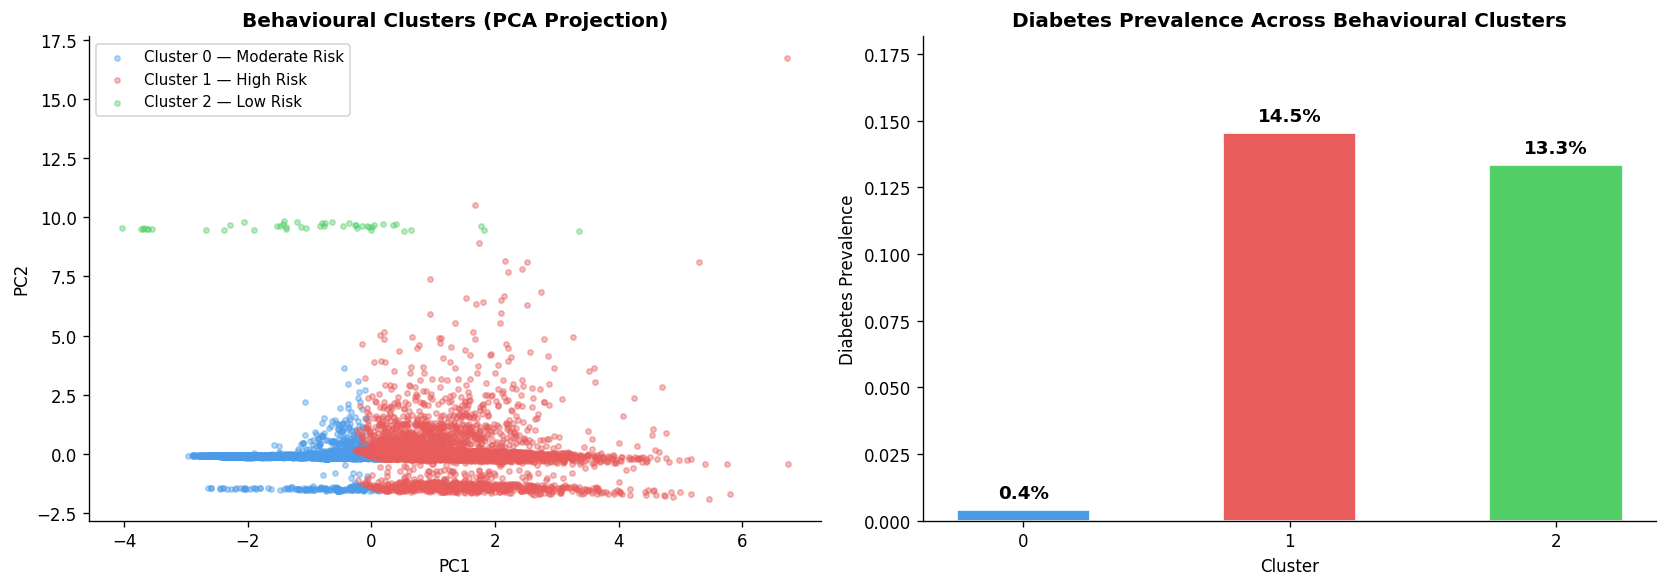


Cluster Profile Summary:
         RIDAGEYR  BMXBMI  BMXWAIST  DRQSDIET  DR1TALCO  Diabetes
Cluster                                                          
0           13.34   19.60     68.12      1.96      1.32      0.00
1           50.17   30.71    103.33      1.81     10.66      0.15
2           47.84   26.74     89.47      9.00      0.00      0.13

Diabetes Prevalence per Cluster:
  Cluster 0 (Moderate Risk): 0.4%
  Cluster 1 (High Risk): 14.5%
  Cluster 2 (Low Risk): 13.3%


In [ ]:
# Fit with K=3
kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster_sc)
df_cluster = df[cluster_features + ['Diabetes']].copy()
df_cluster['Cluster'] = cluster_labels

# PCA for visualization
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_cluster_sc)
df_cluster['PC1'] = X_pca[:, 0]
df_cluster['PC2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cluster_colors = {0: '#4C9BE8', 1: '#E85C5C', 2: '#51CF66'}
cluster_names  = {0: 'Cluster 0 — Moderate Risk', 1: 'Cluster 1 — High Risk', 2: 'Cluster 2 — Low Risk'}

# PCA scatter
for c in [0, 1, 2]:
    sub = df_cluster[df_cluster['Cluster'] == c]
    axes[0].scatter(sub['PC1'], sub['PC2'], c=cluster_colors[c],
                    label=cluster_names[c], alpha=0.4, s=10)
axes[0].set_title('Behavioural Clusters (PCA Projection)', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9)

# Diabetes prevalence per cluster
prev_by_cluster = df_cluster.groupby('Cluster')['Diabetes'].mean()
bars = axes[1].bar(prev_by_cluster.index.astype(str),
                   prev_by_cluster.values,
                   color=[cluster_colors[i] for i in prev_by_cluster.index],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, prev_by_cluster.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[1].set_title('Diabetes Prevalence Across Behavioural Clusters', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Diabetes Prevalence')
axes[1].set_ylim(0, max(prev_by_cluster.values) * 1.25)

plt.tight_layout()
plt.savefig('fig_8_2_clustering.png', bbox_inches='tight', dpi=150)
plt.show()

# Cluster profiling table
print("\nCluster Profile Summary:")
profile = df_cluster.groupby('Cluster')[cluster_features + ['Diabetes']].mean().round(2)
print(profile.to_string())
print("\nDiabetes Prevalence per Cluster:")
for c, prev in prev_by_cluster.items():
    print(f"  Cluster {c} ({cluster_names[c].split('—')[1].strip()}): {prev*100:.1f}%")


## Final Summary

In [ ]:
print("=" * 65)
print("  DIABETES PREDICTION — FINAL MODEL SUMMARY")
print("=" * 65)
print(f"\n{'Model':<22} {'Accuracy':>10} {'Precision':>11} {'Recall':>9} {'F1-Score':>10} {'AUROC':>8}")
print("-" * 75)
for model_name, metrics in results.items():
    print(f"{model_name:<22} {metrics['Accuracy']:>10.6f} {metrics['Precision']:>11.6f} "
          f"{metrics['Recall']:>9.6f} {metrics['F1-score']:>10.6f} {metrics['AUROC']:>8.6f}")
print("=" * 75)

best_model = max(results, key=lambda m: results[m]['AUROC'])
print(f"\n  Best Model: {best_model}")
print(f"  Accuracy  : {results[best_model]['Accuracy']*100:.2f}%")
print(f"  AUROC     : {results[best_model]['AUROC']:.6f}")
print(f"  F1-Score  : {results[best_model]['F1-score']:.6f}")

print("\n  Key SHAP Findings:")
mean_shap_sorted = sorted(zip(FEATURE_NAMES, mean_shap), key=lambda x: -x[1])
for i, (feat, val) in enumerate(mean_shap_sorted[:3], 1):
    print(f"    {i}. {feat} (SHAP={val:.4f})")

print("\n  Clustering (K=3):")
for c, prev in prev_by_cluster.items():
    print(f"    Cluster {c}: Diabetes prevalence = {prev*100:.1f}%")
print("=" * 65)


  DIABETES PREDICTION — FINAL MODEL SUMMARY

Model                    Accuracy   Precision    Recall   F1-Score    AUROC
---------------------------------------------------------------------------
Logistic Regression      0.872651    0.364146  0.884354   0.515873 0.949297
Random Forest            0.947808    0.632768  0.761905   0.691358 0.955978
XGBoost                  0.943111    0.610465  0.714286   0.658307 0.953577

  Best Model: Random Forest
  Accuracy  : 94.78%
  AUROC     : 0.955978
  F1-Score  : 0.691358

  Key SHAP Findings:
    1. LBXGH (SHAP=2.4208)
    2. RIDAGEYR (SHAP=1.5683)
    3. BMXWAIST (SHAP=1.2208)

  Clustering (K=3):
    Cluster 0: Diabetes prevalence = 0.4%
    Cluster 1: Diabetes prevalence = 14.5%
    Cluster 2: Diabetes prevalence = 13.3%
